In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

def add_ring_mean_columns(df, radius_col='radius', n_rings=10):
    for ring_id in range(1, n_rings + 1):
        # Valore medio del raggio dell'anello in Angstrom
        df[f'ring{ring_id}_mean_A'] = df[radius_col] * (ring_id - 0.5) / 10
    return df

native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


# Complesso 1A1U: Piano di complementarità

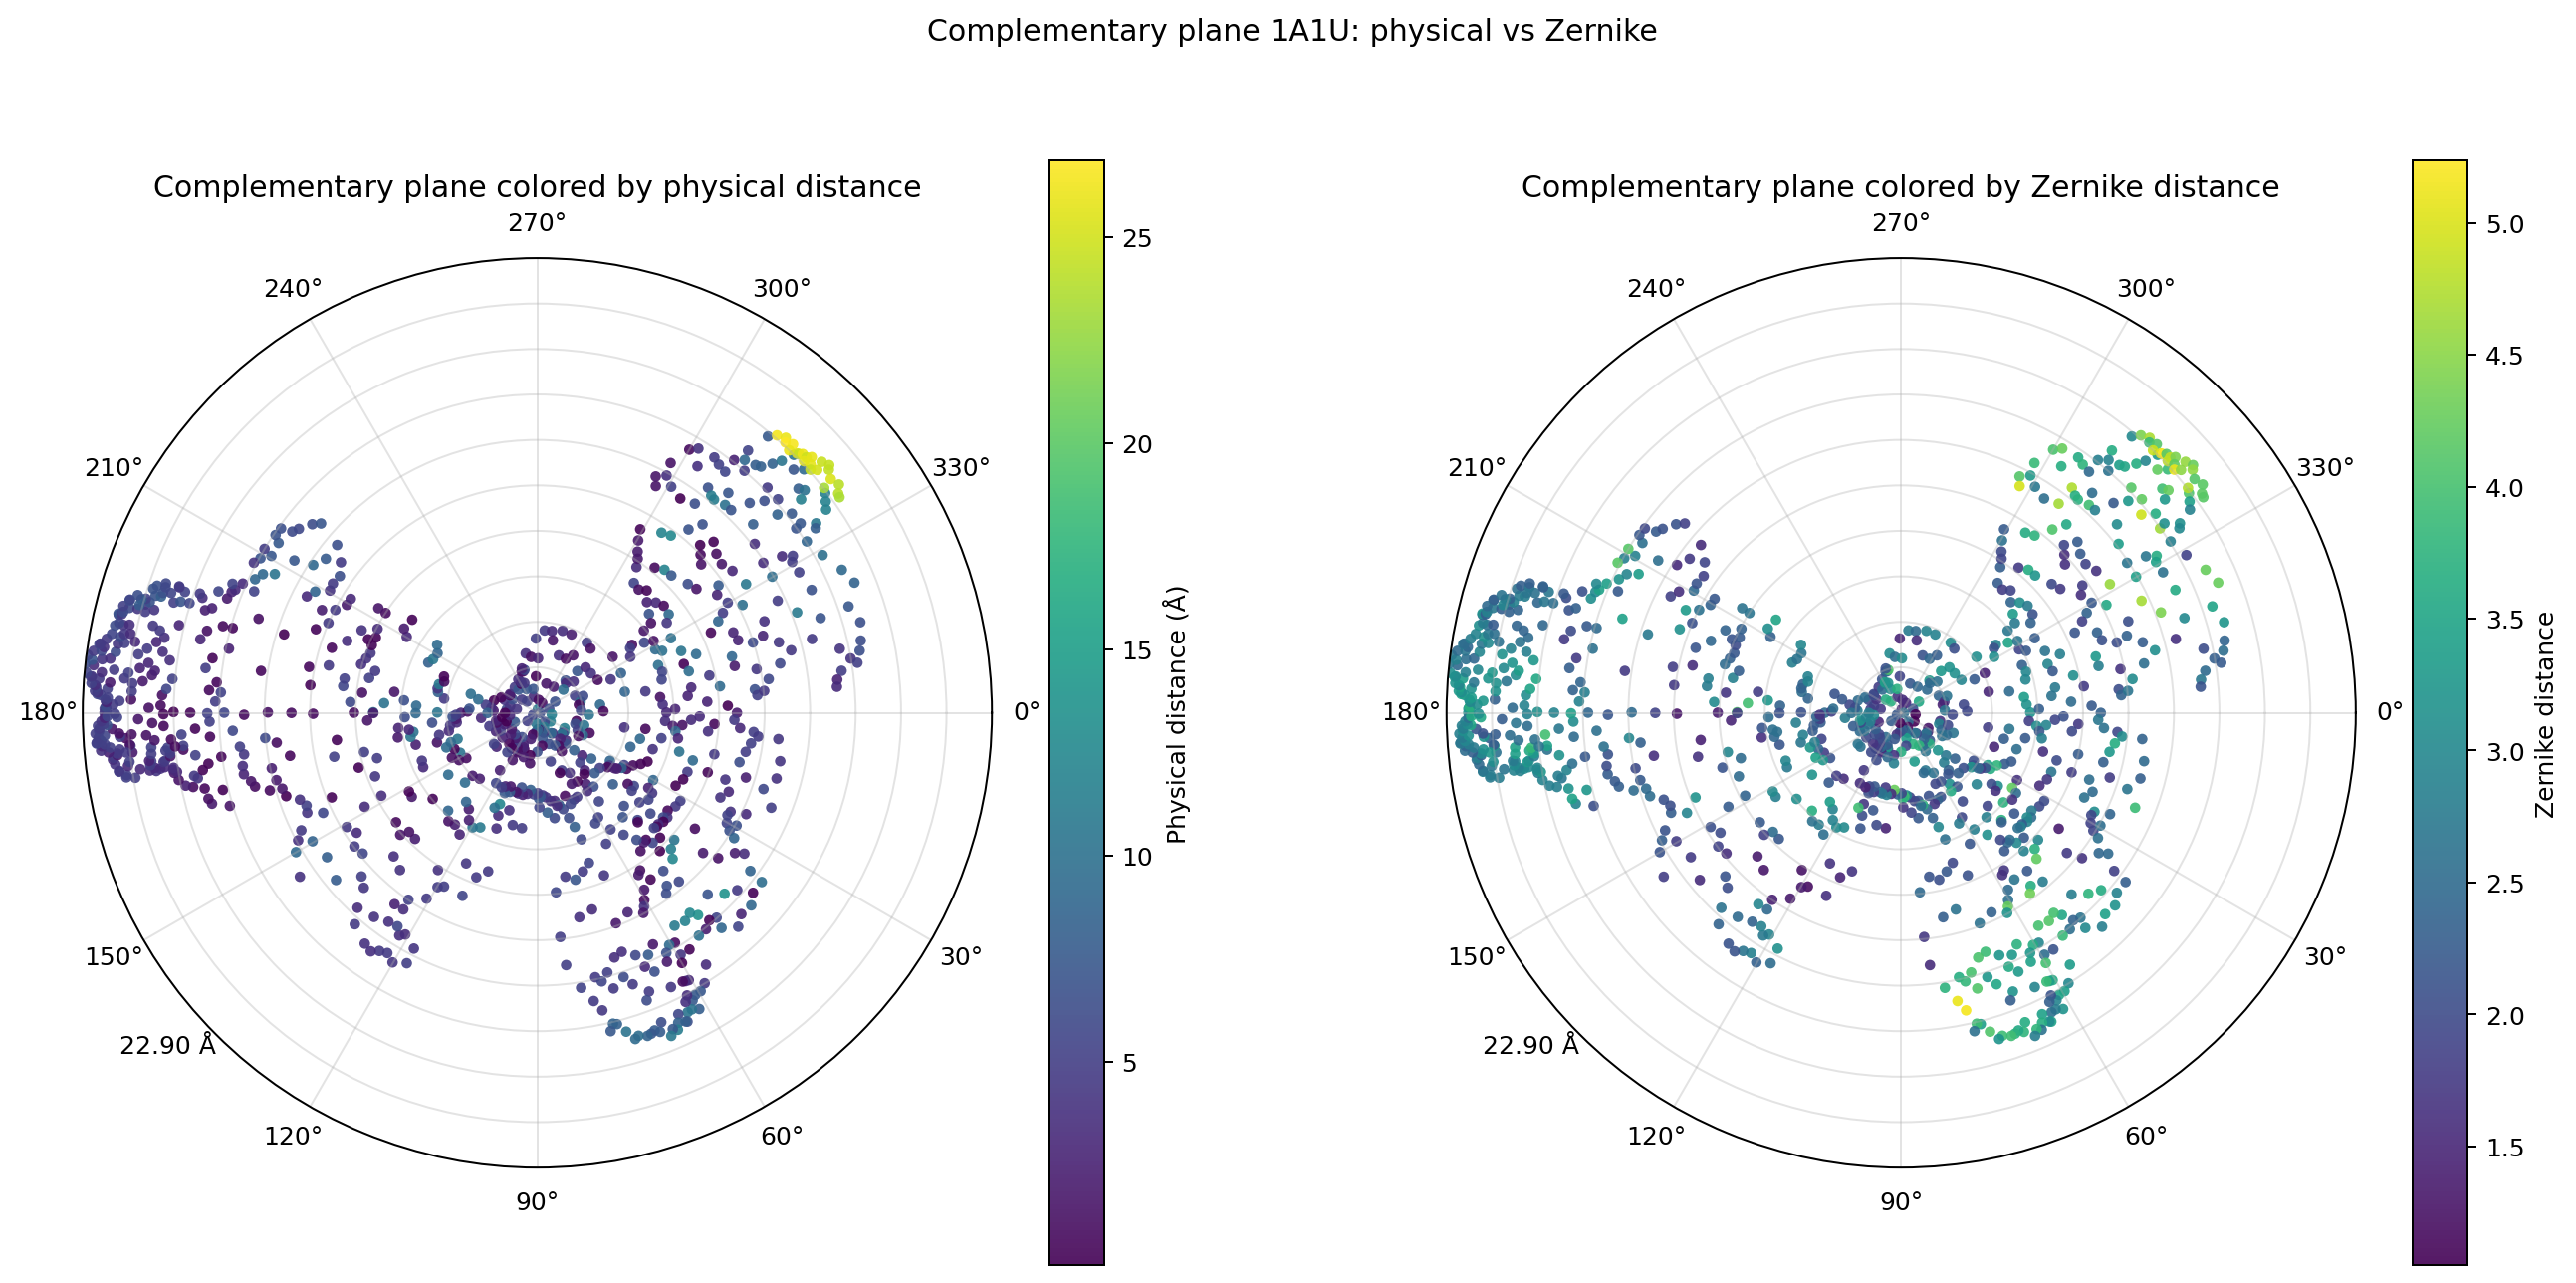

In [4]:
from pathlib import Path
from io import BytesIO
from IPython.display import display, Image

csv_path = Path('output_files/1a1u/default_sampling.csv')

plane_meta = {}
with csv_path.open() as handle:
    for line in handle:
        if not line.startswith('#'):
            break
        key, value = line[1:].split(':', 1)
        plane_meta[key.strip()] = [float(item) for item in value.strip().split(',')]

df_plane = pd.read_csv(csv_path, comment='#')

phys_col = 'physical_distance'
zernike_col = 'zernike_distance'
center_uv = np.array(plane_meta['center_u,center_v'], dtype=float)
circle_radius = float(plane_meta['circle_radius'][0])

dfp = df_plane.dropna(subset=[phys_col, zernike_col]).reset_index(drop=True)

if 'theta' in dfp.columns and 'radial_distance' in dfp.columns:
    theta = dfp['theta'].to_numpy(dtype=float)
    radial = dfp['radial_distance'].to_numpy(dtype=float)
else:
    if {'plane_u', 'plane_v'}.issubset(dfp.columns):
        plane_u = dfp['plane_u'].to_numpy(dtype=float)
        plane_v = dfp['plane_v'].to_numpy(dtype=float)
    else:
        plane_u = dfp['plane_u1'].to_numpy(dtype=float)
        plane_v = dfp['plane_v1'].to_numpy(dtype=float)

    theta = np.arctan2(plane_v - center_uv[1], plane_u - center_uv[0])
    radial = np.hypot(plane_u - center_uv[0], plane_v - center_uv[1])

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': 'polar'})
ring_ticks = np.linspace(circle_radius / 10.0, circle_radius, 10)
theta_labels = [f'{deg}°' for deg in range(0, 360, 30)]
radial_labels = [''] * (len(ring_ticks) - 1) + [f'{circle_radius:.2f} Å']

for ax in axes:
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_rlim(0, circle_radius)
    ax.set_rticks(ring_ticks)
    ax.set_yticklabels(radial_labels)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('right')
        label.set_verticalalignment('top')
    ax.set_thetagrids(np.arange(0, 360, 30), labels=theta_labels)
    ax.grid(True, alpha=0.35)
    ax.set_rlabel_position(135)

sc0 = axes[0].scatter(theta, radial, c=dfp[phys_col], cmap='viridis', s=18, alpha=0.9, edgecolors='none')
axes[0].set_title('Complementary plane colored by physical distance')

sc1 = axes[1].scatter(theta, radial, c=dfp[zernike_col], cmap='viridis', s=18, alpha=0.9, edgecolors='none')
axes[1].set_title('Complementary plane colored by Zernike distance')

cbar0 = fig.colorbar(sc0, ax=axes[0])
cbar0.set_label('Physical distance (Å)')
cbar1 = fig.colorbar(sc1, ax=axes[1])
cbar1.set_label('Zernike distance')

fig.suptitle('Complementary plane 1A1U: physical vs Zernike')
buffer = BytesIO()
fig.savefig(buffer, format='png', dpi=180, bbox_inches='tight')
buffer.seek(0)
display(Image(data=buffer.getvalue()))
out_dir = Path('relazione')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'fig01_1a1u_complementary_plane.pdf', dpi=180, bbox_inches='tight')
plt.close(fig)

# Correlazioni punti 1A1U
La correlazione non è alta, le due distanze racchiudono informazioni diverse

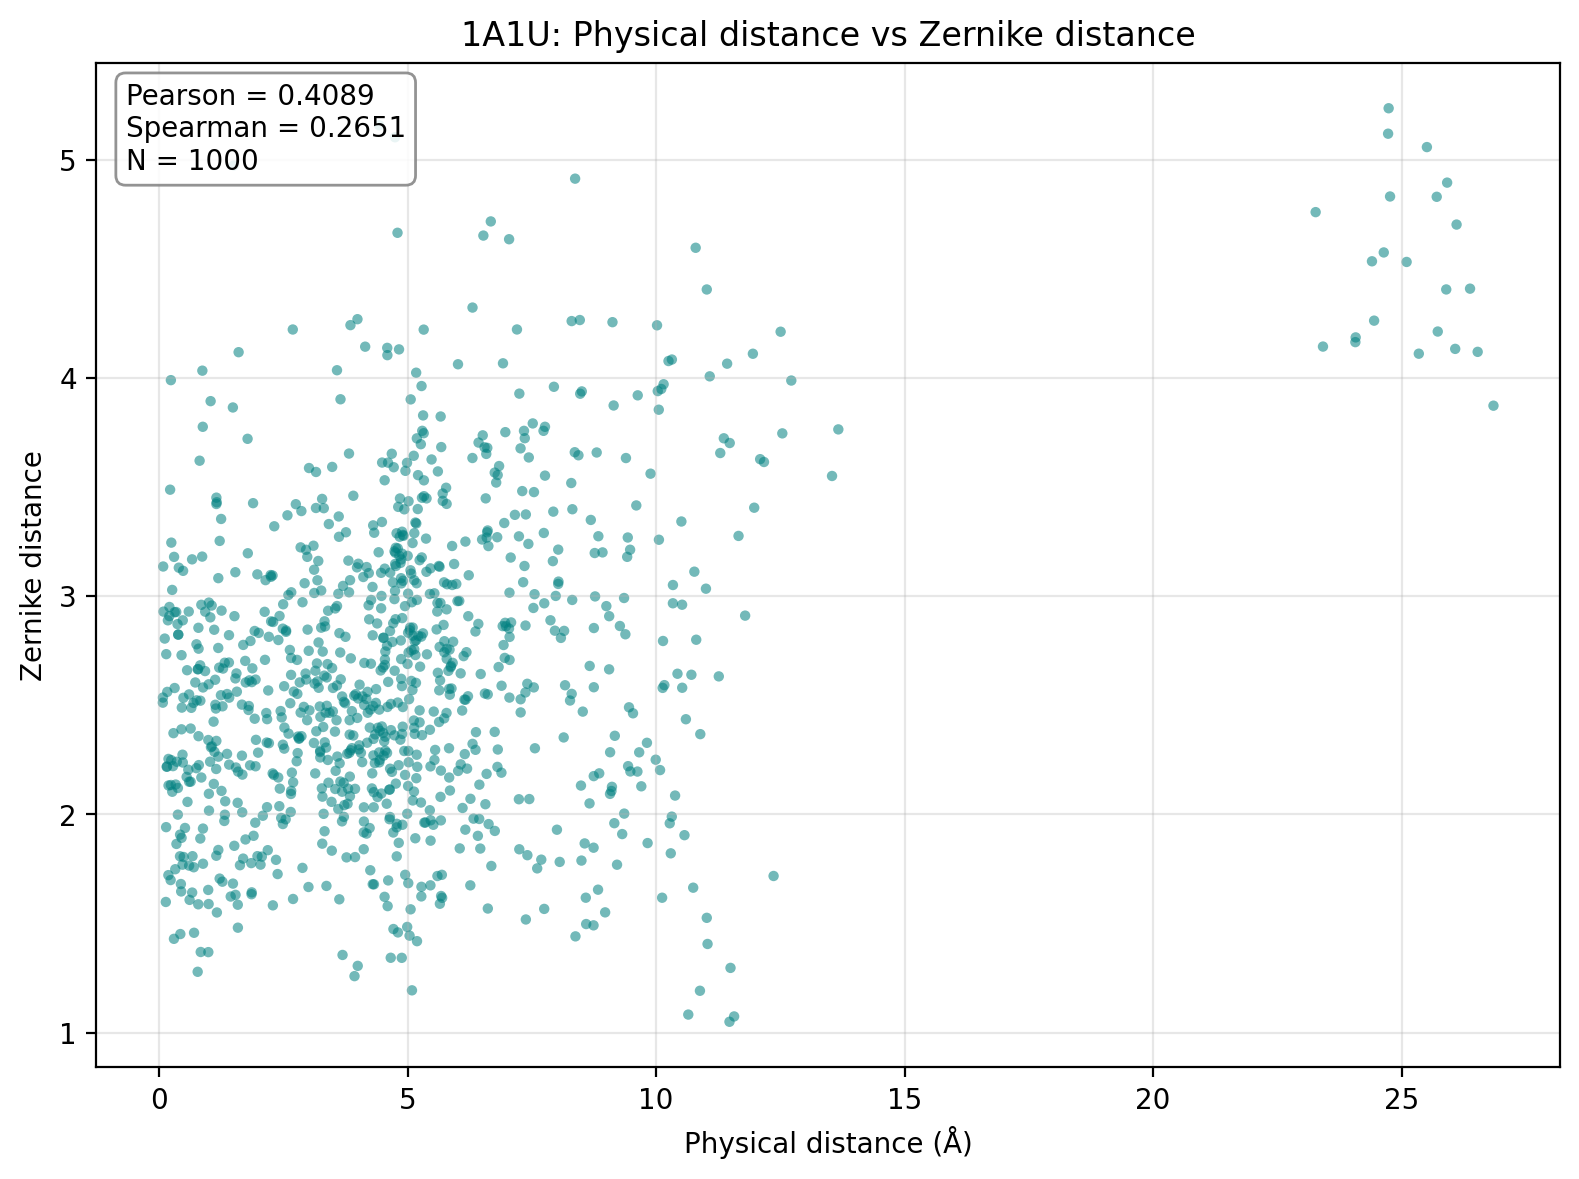

Pearson correlation: 0.408898
Spearman correlation: 0.265135


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('output_files/1a1u/default_sampling.csv')
df_1a1u = pd.read_csv(csv_path, comment='#')

xy = df_1a1u[['physical_distance', 'zernike_distance']].dropna().copy()

pearson_corr = xy['physical_distance'].corr(xy['zernike_distance'], method='pearson')
spearman_corr = xy['physical_distance'].corr(xy['zernike_distance'], method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    xy['physical_distance'],
    xy['zernike_distance'],
    s=14,
    alpha=0.55,
    color='teal',
    edgecolors='none'
)

ax.set_title('1A1U: Physical distance vs Zernike distance')
ax.set_xlabel('Physical distance (Å)')
ax.set_ylabel('Zernike distance')
ax.grid(True, alpha=0.3)

ax.text(
    0.02,
    0.98,
    f"Pearson = {pearson_corr:.4f}\nSpearman = {spearman_corr:.4f}\nN = {len(xy)}",
    transform=ax.transAxes,
    va='top',
    ha='left',
    bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': 'gray'}
)

plt.tight_layout()
plt.savefig('relazione/fig02_1a1u_physical_zernike_correlation.pdf', dpi=180, bbox_inches='tight')
plt.show()

print(f"Pearson correlation: {pearson_corr:.6f}")
print(f"Spearman correlation: {spearman_corr:.6f}")